# Titanic Survival Prediction Using Logistic Regression

### Step 1: Import the modulus

In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Step 2: Collect and preprocess the dataset

In [217]:
dataset = pd.read_csv('titanic_dataset - train.csv')
dataset.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,"712,833",C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,"7,925",S,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,S,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,S,0


In [218]:
dataset.shape

(891, 10)

this dataset have 891 rows and 10 features

In [219]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Name      891 non-null    object 
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    object 
 8   Embarked  891 non-null    object 
 9   Survived  891 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 69.7+ KB


The **info()** method is used to display the column-wise summary of the dataset, which includes the column names, the number of non-null values in each column, the data types of each column, and the amount of memory used by the dataset. The output shows that there are no missing values in the dataset, and the data types of each column are either integer, float, or object (which typically represents strings in pandas).

In [220]:
dataset1 = dataset.drop(['Name','Ticket'], axis=1)

dataset1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.25,S,0
1,1,female,38.0,1,0,"712,833",C,1
2,3,female,26.0,0,0,"7,925",S,1
3,1,female,35.0,1,0,53.1,S,1
4,3,male,35.0,0,0,8.05,S,0


This code drops the `Name` and `Ticket` columns from the original Titanic dataset (stored in the variable 'dataset') and creates a new DataFrame **dataset1** with the remaining columns. 

In [221]:
feature_cat = dataset1[['Sex', 'Fare', 'Embarked']]

feature_cat.head()

,Sex,Fare,Embarked
0,male,7.25,S
1,female,"712,833",C
2,female,"7,925",S
3,female,53.1,S
4,male,8.05,S


In [222]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
feature_encoded = encoder.fit_transform(feature_cat)

feature_encoded[:5]

array([[  1., 173.,   2.],
       [  0., 182.,   0.],
       [  0., 171.,   2.],
       [  0., 141.,   2.],
       [  1., 209.,   2.]])

In [223]:
dataset1['Sex_encoded'] = feature_encoded[: , :1]
dataset1['Fare_encoded'] = feature_encoded[: , 1:2]
dataset1['Embarked_encoded'] = feature_encoded[: , 2:3]

dataset1 = dataset1.drop('Sex',axis=1)
dataset1 = dataset1.drop('Fare',axis=1)
dataset1 = dataset1.drop('Embarked',axis=1)

dataset1.head()

,Pclass,Age,SibSp,Parch,Survived,Sex_encoded,Fare_encoded,Embarked_encoded
0,3,22.0,1,0,0,1.0,173.0,2.0
1,1,38.0,1,0,1,0.0,182.0,0.0
2,3,26.0,0,0,1,0.0,171.0,2.0
3,1,35.0,1,0,1,0.0,141.0,2.0
4,3,35.0,0,0,0,1.0,209.0,2.0


From the code above, we actually change the object into float.

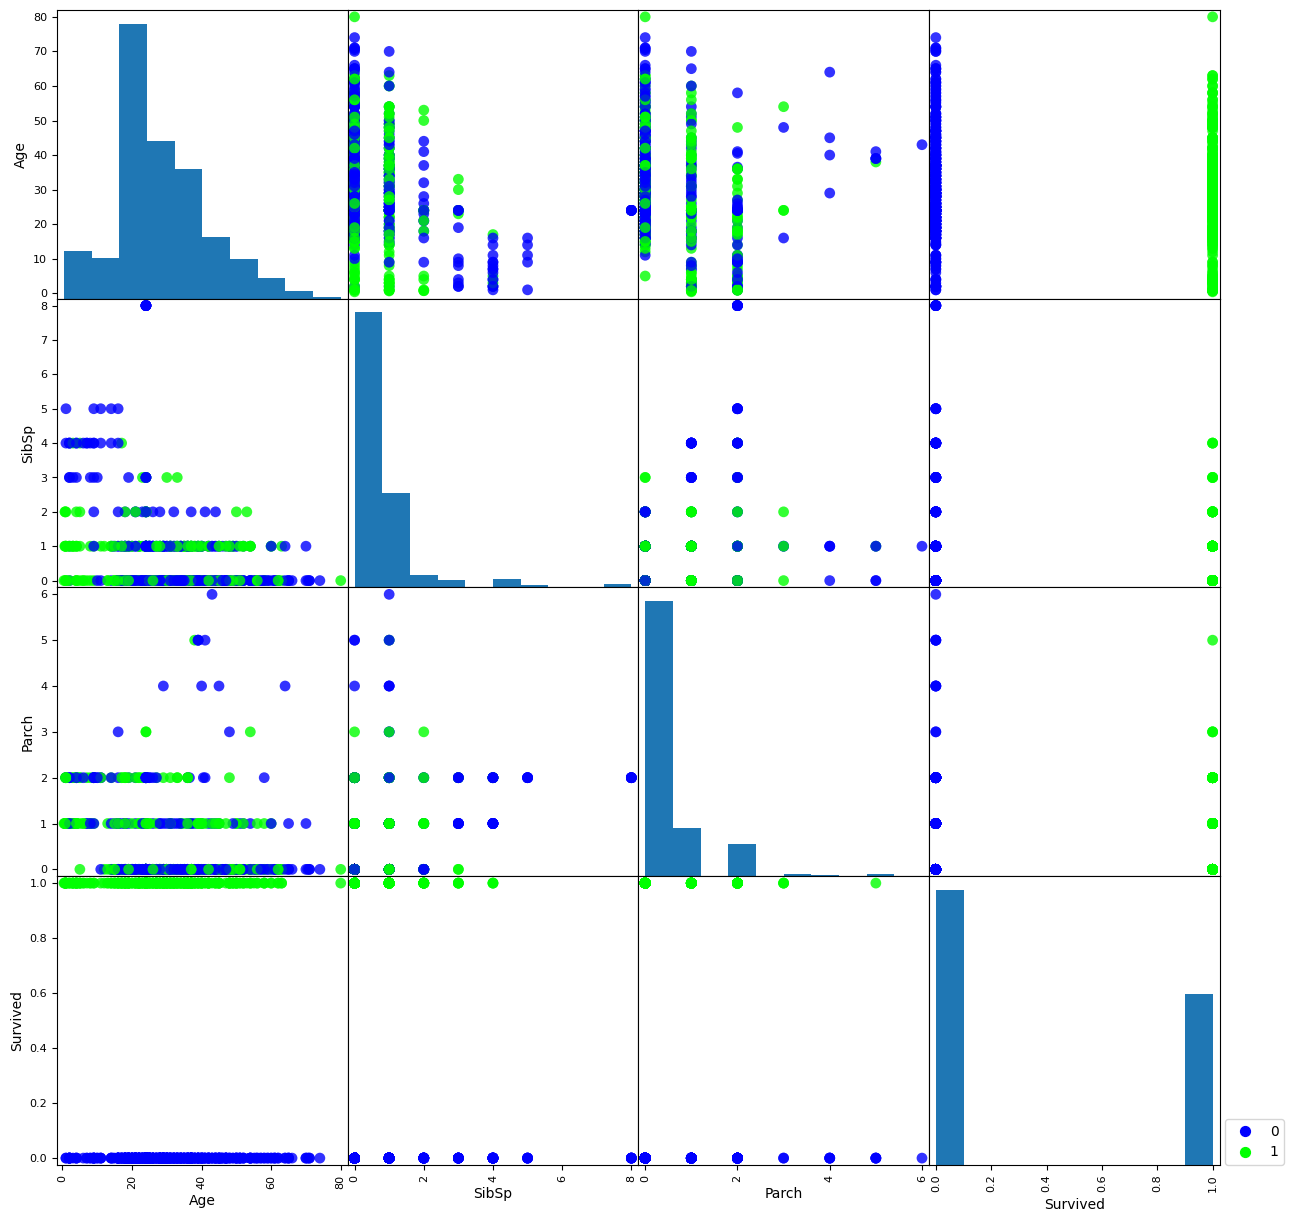

In [224]:
columns = ['Age', 'SibSp', 'Parch', 'Survived']

scatter_matrix = pd.plotting.scatter_matrix(dataset[columns], figsize=(15, 15),c=dataset1['Survived'], marker='o', s=60, alpha=.8, cmap='brg')
handles = [plt.plot([], [], color=plt.cm.brg(i/1.), ls="", marker="o",markersize=np.sqrt(50))[0] for i in range(2)]
labels = ["0", "1"]
plt.legend(labels, loc=(1.02,0))
plt.show()

The plot shows the pairwise relationships between the columns in the scatter matrix. The diagonal of the plot shows the distribution of each variable. The plot points are colored based on whether the passenger survived or not. The legend shows which color corresponds to each class. The plot can be used to visually identify any patterns or relationships between the variables in the dataset.

In [225]:
corr_matrix = dataset1.corr()

corr_matrix['Survived'].sort_values(ascending=False)

Survived            1.000000
Parch               0.081629
SibSp              -0.035322
Age                -0.047255
Fare_encoded       -0.132191
Embarked_encoded   -0.170943
Pclass             -0.338481
Sex_encoded        -0.543351
Name: Survived, dtype: float64

Meaning of the correlation figure is explained by above `corr_matrix`. Correlation value 1.0 shows that strong positive corelation between feature and -1.0 shows the strong negative correlation.  

In our dataset, `Parch` is the most feature that relate to the `Survived` as shown as the correlation value is 0.081629. This is related to the correlation figure that correlation between these two values is the most linear compare to the others. 

In [226]:
data = dataset1.drop('Survived', axis=1)
labels = dataset1['Survived'].copy()

Drop the Survived feature as a target feature in this dataset

In [227]:
labels = labels.values.reshape(-1, 1)
labels.shape

(891, 1)

In [228]:
data.head()

,Pclass,Age,SibSp,Parch,Sex_encoded,Fare_encoded,Embarked_encoded
0,3,22.0,1,0,1.0,173.0,2.0
1,1,38.0,1,0,0.0,182.0,0.0
2,3,26.0,0,0,0.0,171.0,2.0
3,1,35.0,1,0,0.0,141.0,2.0
4,3,35.0,0,0,1.0,209.0,2.0


### Step 3: Split the dataset

In [229]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=0)

This code is splitting the dataset data into two parts: a training set and a testing set, along with their corresponding labels labels. The split is performed using the train_test_split function from sklearn.model_selection. The training set will contain 80% of the data, and the testing set will contain 20%. The random_state parameter sets the random seed, ensuring that the same split is obtained each time the code is run. 

### Step 4: Build and train the model

In [230]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train, y_train)

train_pred = model.predict(x_train)

The code above is training a logistic regression model on the training data x_train and y_train using scikit-learn's LogisticRegression class. After fitting the model with the fit() method, the code predicts the class labels for the training data using the predict() method and saves the predictions in the train_pred variable.

In [231]:
from sklearn import metrics
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_pred)
print('Train Accuracy:', round(train_acc*100, 2), '%')

Train Accuracy: 80.76 %


The code above calculates the training accuracy of a logistic regression model.
First, the code imports the necessary libraries for model evaluation, including metrics and accuracy_score from scikit-learn.
Then, it calculates the predicted labels of the training set using the trained logistic regression model and the predict method.
Next, it calculates the accuracy score of the predicted labels compared to the actual labels of the training set using the accuracy_score method.
The code prints the training accuracy rounded to two decimal places as a percentage.

In [232]:
cnf_matrix = metrics.confusion_matrix(y_train, train_pred)
cnf_matrix

array([[384,  55],
       [ 82, 191]], dtype=int64)

The confusion matrix is a table that is often used to describe the performance of a classification model. It shows the number of true positives, false positives, true negatives, and false negatives, in a matrix format. The rows of the matrix represent the actual labels, while the columns represent the predicted labels. Therefore, the diagonal elements of the matrix represent the number of correct predictions, while the off-diagonal elements represent the misclassifications.

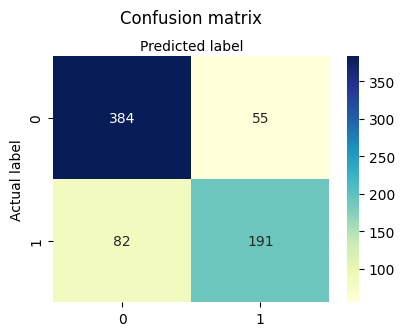

In [233]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [0,1]
fig, ax = plt.subplots(figsize=[4,3])
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap='YlGnBu', fmt='g')
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.title('Confusion matrix',y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()

The code is used to visualize the confusion matrix for the logistic regression model on the training data. 

In [234]:
from sklearn.metrics import classification_report

target_names = ['0', '1']
print(classification_report(y_train, train_pred, target_names = target_names))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       439
           1       0.78      0.70      0.74       273

    accuracy                           0.81       712
   macro avg       0.80      0.79      0.79       712
weighted avg       0.81      0.81      0.81       712



In [235]:
model.get_params()
print('Intercept of linear regression model (beta 0):', model.intercept_)
print('Co-efficient of linear regression (beta 1):', model.coef_)

Intercept of linear regression model (beta 0): [5.44674625]
Co-efficient of linear regression (beta 1): [[-1.20035256e+00 -4.80942466e-02 -3.71573055e-01 -8.78236143e-03
  -2.61642220e+00  2.12813271e-03 -1.67453244e-01]]


The coefficients indicate the impact of the corresponding feature on the Survived feature, with positive values indicating a positive correlation and negative values indicating a negative correlation.

### Step 5: Evalulate the model

In [236]:
test_pred = model.predict(x_test)

test_acc = accuracy_score(y_test, test_pred)
print('Test Accuracy:', round(test_acc*100,2), '%')

Test Accuracy: 81.01 %


This code is predicting the labels of the test data using the trained logistic regression model, and then calculating the accuracy of the model on the test data.It calculates the accuracy of the model on the test data by comparing the predicted labels with the actual labels of the test data, and then computing the percentage of correct predictions.

In [237]:
cnf_matrix = metrics.confusion_matrix(y_test, test_pred)
cnf_matrix

array([[94, 16],
       [18, 51]], dtype=int64)

Text(0.5, 269.55555555555554, 'Predicted label')

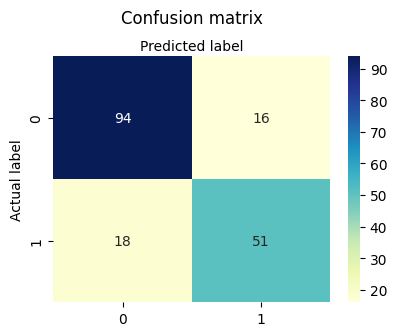

In [238]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [0,1]
fig, ax =plt.subplots(figsize=[4,3])
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap='YlGnBu', fmt='g')
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

The code is used to visualize the confusion matrix for the logistic regression model on the testing data. 

In [239]:
test_data = pd.DataFrame(data=x_test)
test_data['Survived'] = y_test
test_data['test_prediction'] = test_pred

test_data[['Survived', 'test_prediction']]

,Survived,test_prediction
495,0,0
648,0,0
278,0,0
31,1,1
255,1,1
...,...,...
780,1,1
837,0,0
215,1,1
833,0,0


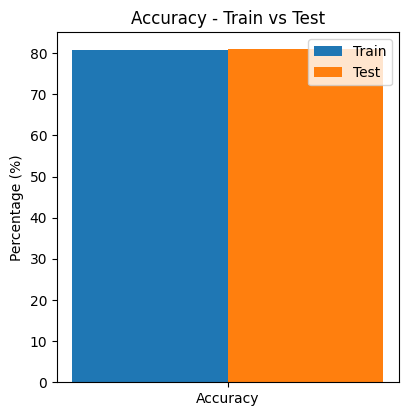

In [240]:
labels1 = ['Accuracy']

data1 = range(len(labels1))
width = 0.4

fig = plt.figure(figsize=[15,10])
ax1 = fig.add_subplot(2, 3, 1)
ax1.bar(data1, train_acc*100, width, label='Train')
ax1.bar(width, test_acc*100, width, label='Test')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Accuracy - Train vs Test')
ax1.set_xticks([i+width/2 for i in data1])
ax1.set_xticklabels(labels1)
ax1.legend()

plt.show()

This code generates a bar plot showing the accuracy of the model on the training and testing datasets. It shows that the accuracy of testing data is slitly higher than training data.

### Step 6: Deploy the model

Finally, after conducting multiple predictions on the training and testing sets, we are now ready to deploy our model and make predictions on actual given data.

In [243]:
new_data = pd.read_csv('titanic_prediction - test.csv')
new_data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,"78,292",Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,"96,875",Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,"86,625",S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,"122,875",S


In [244]:
new_data.shape

(418, 9)

In [245]:
new_data.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [246]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      418 non-null    object 
 8   Embarked  418 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 29.5+ KB


In [247]:
new_data1 = new_data.drop(['Name','Ticket'], axis=1)

new_data1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,"78,292",Q
1,3,female,47.0,1,0,7,S
2,2,male,62.0,0,0,"96,875",Q
3,3,male,27.0,0,0,"86,625",S
4,3,female,22.0,1,1,"122,875",S


In [248]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
new_data2 = new_data1.copy()

Sex_encoded = encoder.fit_transform(new_data1[['Sex']])
Fare_encoded = encoder.fit_transform(new_data1[['Fare']])
Embarked_encoded = encoder.fit_transform(new_data1[['Embarked']])


In [249]:
new_data2['Sex_encoded'] = Sex_encoded
new_data2['Fare_encoded'] = Fare_encoded
new_data2['Embarked_encoded'] = Embarked_encoded

new_data2.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_encoded,Fare_encoded,Embarked_encoded
0,3,male,34.5,0,0,"78,292",Q,1.0,146.0,1.0
1,3,female,47.0,1,0,7,S,0.0,120.0,2.0
2,2,male,62.0,0,0,"96,875",Q,1.0,168.0,1.0
3,3,male,27.0,0,0,"86,625",S,1.0,159.0,2.0
4,3,female,22.0,1,1,"122,875",S,0.0,13.0,2.0


In [250]:
new_data2 = new_data2.drop('Sex', axis=1)
new_data2 = new_data2.drop('Fare', axis=1)
new_data2 = new_data2.drop('Embarked', axis=1)

new_data2.head()

,Pclass,Age,SibSp,Parch,Sex_encoded,Fare_encoded,Embarked_encoded
0,3,34.5,0,0,1.0,146.0,1.0
1,3,47.0,1,0,0.0,120.0,2.0
2,2,62.0,0,0,1.0,168.0,1.0
3,3,27.0,0,0,1.0,159.0,2.0
4,3,22.0,1,1,0.0,13.0,2.0


In [251]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [252]:
predictions = model.predict(new_data2)

In [253]:
new_data['Predictions'] = predictions
new_data.to_csv('titanic_prediction - test.csv', index=False)

In [254]:
new_data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Predictions
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,"78,292",Q,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,S,0
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,"96,875",Q,0
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,"86,625",S,0
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,"122,875",S,1


In [255]:
new_data.to_csv('S67562_Titanic_Predictions.csv')

## _______________________________THE END_______________________________